# 04 – Derin Öğrenme (LSTM + Transformer)

**Proje:** EUR/USD 1H Forex Zaman Serisi Tahmini  
**Ders:** Yapay Zekaya Giriş – Dönem Projesi (Hafta 6 Teslimi)  
**Öğrenci:** Bilal – `b200101025`

## Amaç

Hafta 4–5 baseline'ları ve GBDT'leri tabanı çizdi; RMSE çok sıkı band üzerinde, ama yön doğrulukları GBDT'lerle %1.5 puan yükseldi. Bu defterde **aynı girdi uzayında** iki küçük derin model çalıştırıyoruz:

1. **LSTM** – 2 katman, gizli 64; sekans girdisini recurrent olarak tarar.
2. **Transformer Encoder** – 2 katman, d_model=32, 2 head; self-attention ile lag ilişkilerini havuzlar.

Her iki model de sabit pencereli **(B, L, F)** girdisini tek bir skaler tahmine bağlar: `y_{t+1} = f(X_{t-L+1..t})`. Bu Hafta 5 protokolüyle aynı, sadece feature dizilimi kısa zaman penceresi olarak serileşmiş olur.

### Neden bu boyutlar?

- CPU'da çalışıyoruz; eğitim dakikalar mertebesinde kalmalı.
- İstenen ana mesaj: "DL baseline/GBDT tabanını anlamlı bir farkla kırabiliyor mu?" Pahalı devler bu soruya gerek yok; küçük net bir cevap vermek yeterli.

## 0. Ortam ve Cihaz

In [1]:
from __future__ import annotations

import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_raw_eurusd, train_val_test_split
from src.features import build_feature_frame
from src.metrics import score_all
from src.models.deep import LSTMForecaster, TransformerForecaster, count_parameters

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['figure.dpi'] = 100

RAW_CSV = PROJECT_ROOT / 'data' / 'raw' / 'eurusd_h1.csv'
FIG_DIR = PROJECT_ROOT / 'docs' / 'images'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch  : {torch.__version__}')
print(f'device : {DEVICE}   (threads={torch.get_num_threads()})')

torch  : 2.11.0+cpu
device : cpu   (threads=6)


## 1. Veri + Feature Hazırlığı

Hafta 5 ile birebir aynı feature tablosu; hedef yine `log_ret_{t+1}`. Tek fark: derin ağa girerken **train istatistikleriyle standardize** ediyoruz (robust-z).

In [2]:
raw = load_raw_eurusd(RAW_CSV)
feats = build_feature_frame(raw)
feats['target'] = feats['log_ret_1'].shift(-1)
feats = feats.dropna()

DROP = ['target', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume', 'ret_1', 'log_ret_1']
FEATURE_COLS = [c for c in feats.columns if c not in DROP]
train, val, test = train_val_test_split(feats)
print(f'train {len(train):,}  val {len(val):,}  test {len(test):,}   feature={len(FEATURE_COLS)}')

mu = train[FEATURE_COLS].median()
sd = (train[FEATURE_COLS].quantile(0.75) - train[FEATURE_COLS].quantile(0.25)) / 1.349 + 1e-9  # robust std
def z(x: pd.DataFrame) -> np.ndarray:
    return ((x[FEATURE_COLS] - mu) / sd).values.astype(np.float32)
X_tr, X_va, X_te = z(train), z(val), z(test)
y_tr, y_va, y_te = train['target'].values.astype(np.float32), val['target'].values.astype(np.float32), test['target'].values.astype(np.float32)

train 81,755  val 6,206  test 12,476   feature=29


## 2. Sliding Window Dataset

Pencere uzunluğu `L=48` saat (2 gün) — 1H serisi için sağduyulu başlangıç; genişlemeler Hafta 8'de denenecek.

Split arası kaçağı önlemek için test başlangıcına ilk `L-1` öncü satırı train'den **değil** onceki segmentten konteks olarak alıyoruz (`build_windows` fonksiyonu).

In [3]:
SEQ_LEN = 48
BATCH = 512

def build_windows(X: np.ndarray, y: np.ndarray, L: int = SEQ_LEN):
    """(N-L+1, L, F) pencereler + (N-L+1,) hedef."""
    n = len(X) - L + 1
    if n <= 0:
        raise ValueError('Yetersiz uzunluk')
    Xw = np.stack([X[i:i+L] for i in range(n)])
    yw = y[L-1:]
    return Xw, yw

X_tr_w, y_tr_w = build_windows(X_tr, y_tr)
X_va_w, y_va_w = build_windows(np.vstack([X_tr[-SEQ_LEN+1:], X_va]), np.concatenate([y_tr[-SEQ_LEN+1:], y_va]))
# val kaymasız olsun diye ilk SEQ_LEN-1'i atıyoruz
X_va_w = X_va_w[SEQ_LEN-1:]; y_va_w = y_va_w[SEQ_LEN-1:]
X_te_w, y_te_w = build_windows(np.vstack([X_va[-SEQ_LEN+1:], X_te]), np.concatenate([y_va[-SEQ_LEN+1:], y_te]))
X_te_w = X_te_w[SEQ_LEN-1:]; y_te_w = y_te_w[SEQ_LEN-1:]

print(f'train windows: {X_tr_w.shape}   val: {X_va_w.shape}   test: {X_te_w.shape}')

def make_loader(X, y, shuffle):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_tr_w, y_tr_w, shuffle=True)
val_loader   = make_loader(X_va_w, y_va_w, shuffle=False)
test_loader  = make_loader(X_te_w, y_te_w, shuffle=False)

train windows: (81708, 48, 29)   val: (6159, 48, 29)   test: (12429, 48, 29)


## 3. Eğitim İskeleti

Adam lr=1e-3, MSE; en iyi val RMSE'li checkpoint saklanır (early-stop benzeri). Maks 5 epoch; CPU'da LSTM ~20 sn/epoch, Transformer ~15 sn/epoch civarı.

In [4]:
def evaluate_on(model, loader) -> np.ndarray:
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(preds)

def train_model(model, epochs: int = 5, lr: float = 1e-3, clip: float = 1.0) -> dict:
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_val = float('inf'); best_state = None
    history = {'train': [], 'val': []}
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train(); tr_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            tr_losses.append(loss.item())
        tr_loss = float(np.mean(tr_losses))
        val_pred = evaluate_on(model, val_loader)
        val_loss = float(np.mean((val_pred - y_va_w) ** 2))
        history['train'].append(tr_loss); history['val'].append(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f'  epoch {epoch}/{epochs}  train_mse={tr_loss:.3e}  val_mse={val_loss:.3e}  best_val={best_val:.3e}  ({time.time()-t0:.1f}s)')
    model.load_state_dict(best_state)
    return history

## 4. LSTM

In [5]:
lstm = LSTMForecaster(input_size=len(FEATURE_COLS), hidden_size=64, num_layers=2, dropout=0.2)
print(f'LSTM params: {count_parameters(lstm):,}')
hist_lstm = train_model(lstm, epochs=5, lr=1e-3)

val_pred_lstm = evaluate_on(lstm, val_loader)
test_pred_lstm = evaluate_on(lstm, test_loader)

LSTM params: 57,665


  epoch 1/5  train_mse=2.230e-05  val_mse=1.224e-06  best_val=1.224e-06  (12.8s)


  epoch 2/5  train_mse=2.060e-06  val_mse=1.119e-06  best_val=1.119e-06  (24.3s)


  epoch 3/5  train_mse=1.719e-06  val_mse=1.020e-06  best_val=1.020e-06  (36.2s)


  epoch 4/5  train_mse=1.621e-06  val_mse=1.028e-06  best_val=1.020e-06  (47.8s)


  epoch 5/5  train_mse=1.523e-06  val_mse=1.069e-06  best_val=1.020e-06  (59.3s)


## 5. Transformer Encoder

In [6]:
tfm = TransformerForecaster(input_size=len(FEATURE_COLS), seq_len=SEQ_LEN, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1)
print(f'Transformer params: {count_parameters(tfm):,}')
hist_tfm = train_model(tfm, epochs=6, lr=5e-4)

val_pred_tfm = evaluate_on(tfm, val_loader)
test_pred_tfm = evaluate_on(tfm, test_loader)

Transformer params: 72,129


  epoch 1/6  train_mse=3.407e-06  val_mse=1.170e-06  best_val=1.170e-06  (59.5s)


  epoch 2/6  train_mse=1.459e-06  val_mse=1.047e-06  best_val=1.047e-06  (119.1s)


  epoch 3/6  train_mse=1.543e-06  val_mse=1.286e-06  best_val=1.047e-06  (179.4s)


  epoch 4/6  train_mse=1.479e-06  val_mse=1.061e-06  best_val=1.047e-06  (240.7s)


  epoch 5/6  train_mse=1.477e-06  val_mse=1.206e-06  best_val=1.047e-06  (300.8s)


  epoch 6/6  train_mse=1.484e-06  val_mse=1.150e-06  best_val=1.047e-06  (361.5s)


## 6. Eğitim Eğrileri

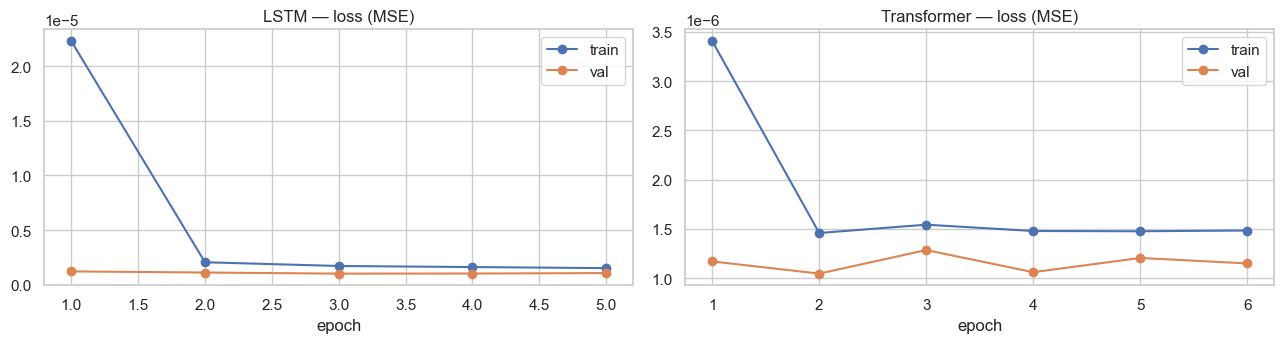

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, (name, h) in zip(axes, [('LSTM', hist_lstm), ('Transformer', hist_tfm)]):
    epochs = range(1, len(h['train']) + 1)
    ax.plot(epochs, h['train'], marker='o', label='train')
    ax.plot(epochs, h['val'],   marker='o', label='val')
    ax.set_title(f'{name} — loss (MSE)')
    ax.set_xlabel('epoch')
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'dl_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Skorlama ve Birleşik Tablo

Sliding window yapısı yüzünden val/test tahminleri `SEQ_LEN-1` kadar kaymış başlar; o hizayı kapatıp close rekonstrüksiyonu yapıyoruz.

In [8]:
def align_and_score(model_name: str, val_pred: np.ndarray, test_pred: np.ndarray) -> list[dict]:
    rows = []
    val_seg = val.iloc[SEQ_LEN-1:]
    test_seg = test.iloc[SEQ_LEN-1:]
    prev_val = float(val.iloc[SEQ_LEN-2]['close']) if SEQ_LEN > 1 else float(train['close'].iloc[-1])
    prev_te = float(test.iloc[SEQ_LEN-2]['close']) if SEQ_LEN > 1 else float(val['close'].iloc[-1])
    val_close_pred = np.concatenate([[prev_val], val_seg['close'].values[:-1]]) * np.exp(val_pred)
    test_close_pred = np.concatenate([[prev_te], test_seg['close'].values[:-1]]) * np.exp(test_pred)

    sc_v = score_all(val_seg['target'].values, val_pred, val_seg['close'].values, val_close_pred)
    sc_v.update(split='val', model=model_name)
    sc_t = score_all(test_seg['target'].values, test_pred, test_seg['close'].values, test_close_pred)
    sc_t.update(split='test', model=model_name)
    rows.extend([sc_v, sc_t])
    for d in rows:
        print(f"{d['split']:>4}  {model_name:<12}  rmse_ret_bp={d['rmse_ret_bp']:7.3f}  rmse_close_pip={d['rmse_close_pip']:7.3f}  dir_acc%={d['dir_acc_pct']:6.2f}")
    return rows

rows_lstm = align_and_score('lstm', val_pred_lstm, test_pred_lstm)
print()
rows_tfm = align_and_score('transformer', val_pred_tfm, test_pred_tfm)

 val  lstm          rmse_ret_bp= 10.101  rmse_close_pip= 11.223  dir_acc%= 49.69
test  lstm          rmse_ret_bp=  9.707  rmse_close_pip= 10.926  dir_acc%= 50.47

 val  transformer   rmse_ret_bp= 10.230  rmse_close_pip= 11.881  dir_acc%= 52.11
test  transformer   rmse_ret_bp= 10.085  rmse_close_pip= 11.886  dir_acc%= 49.91


In [9]:
dl_scores = pd.DataFrame(rows_lstm + rows_tfm)[['split', 'model', 'rmse_ret_bp', 'mae_ret_bp', 'rmse_close_pip', 'mae_close_pip', 'mape_close', 'dir_acc_pct']]
dl_scores.to_csv(PROC_DIR / 'dl_scores.csv', index=False)

prev = pd.read_csv(PROC_DIR / 'all_model_scores.csv')
combined = pd.concat([prev, dl_scores], ignore_index=True).drop_duplicates(subset=['split', 'model'], keep='last')
combined.to_csv(PROC_DIR / 'all_model_scores.csv', index=False)
combined.round(3).set_index(['split', 'model']).sort_index()

rmse_ret_bp  mae_ret_bp  rmse_close_pip  \
split model                                                          
test  ar(1)                      9.125       5.791          10.062   
      drift                      9.126       5.791          10.063   
      lightgbm                   9.155       5.795          10.183   
      lstm                       9.707       6.433          10.926   
      ma_24h                     9.302       6.009          10.258   
      naive_last_value           9.126       5.791          10.063   
      random_forest              9.139       5.792          10.139   
      seasonal_naive_168h       12.807       8.513          14.137   
      seasonal_naive_24h        12.845       8.423          14.173   
      transformer               10.085       7.026          11.886   
      xgboost                    9.147       5.791          10.169   
val   ar(1)                      9.617       6.323          10.392   
      drift                      9.616       6.323          10.392   
      lightgbm                   9.610       6.316          10.492   
      lstm                      10.101       6.911          11.223   
      ma_24h                     9.816       6.582          10.607   
      naive_last_value           9.616       6.323          10.392   
      random_forest              9.605       6.317          10.458   
      seasonal_naive_168h       13.492       9.100          14.590   
      seasonal_naive_24h        13.675       9.139          14.772   
      transformer               10.230       7.007          11.881   
      xgboost                    9.606       6.316          10.468   

                           mae_close_pip  mape_close  dir_acc_pct  
split model                                                        
test  ar(1)                        6.401       0.058       49.939  
      drift                        6.402       0.058       49.657  
      lightgbm                     6.559       0.059       51.276  
      lstm                         7.276       0.066       50.466  
      ma_24h                       6.642       0.060       49.915  
      naive_last_value             6.401       0.058        0.000  
      random_forest                6.547       0.059       51.341  
      seasonal_naive_168h          9.411       0.085       49.729  
      seasonal_naive_24h           9.310       0.084       50.521  
      transformer                  8.326       0.075       49.915  
      xgboost                      6.568       0.059       51.527  
val   ar(1)                        6.835       0.063       50.365  
      drift                        6.836       0.063       49.813  
      lightgbm                     7.013       0.065       52.084  
      lstm                         7.734       0.072       49.689  
      ma_24h                       7.115       0.066       50.024  
      naive_last_value             6.835       0.063        0.000  
      random_forest                6.975       0.065       51.598  
      seasonal_naive_168h          9.839       0.091       50.592  
      seasonal_naive_24h           9.877       0.091       49.943  
      transformer                  8.221       0.076       52.109  
      xgboost                      7.007       0.065       51.890

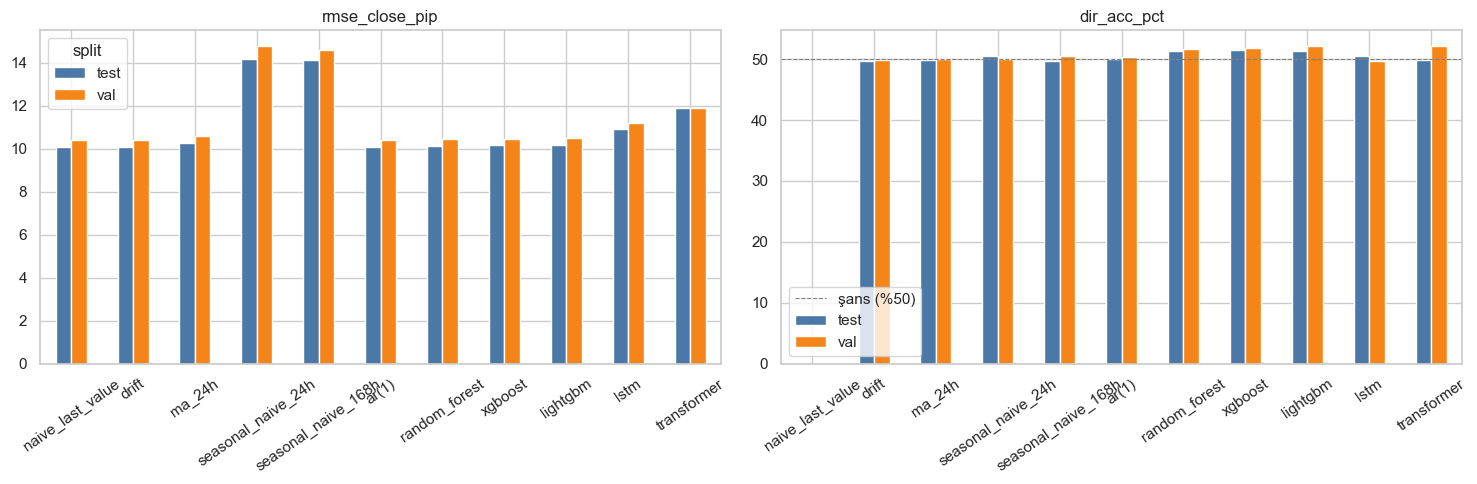

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ar_name = [m for m in combined['model'].unique() if m.startswith('ar(')][0]
order = ['naive_last_value', 'drift', 'ma_24h', 'seasonal_naive_24h', 'seasonal_naive_168h', ar_name,
         'random_forest', 'xgboost', 'lightgbm', 'lstm', 'transformer']
for ax, metric in zip(axes, ['rmse_close_pip', 'dir_acc_pct']):
    piv = combined.pivot(index='model', columns='split', values=metric).loc[order]
    piv.plot(kind='bar', ax=ax, rot=35, color=['#4c78a8', '#f58518'])
    ax.set_title(metric); ax.set_xlabel('')
axes[1].axhline(50, color='gray', ls='--', lw=0.8, label='şans (%50)'); axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'dl_vs_all.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Tahmin vs Gerçek (Test)

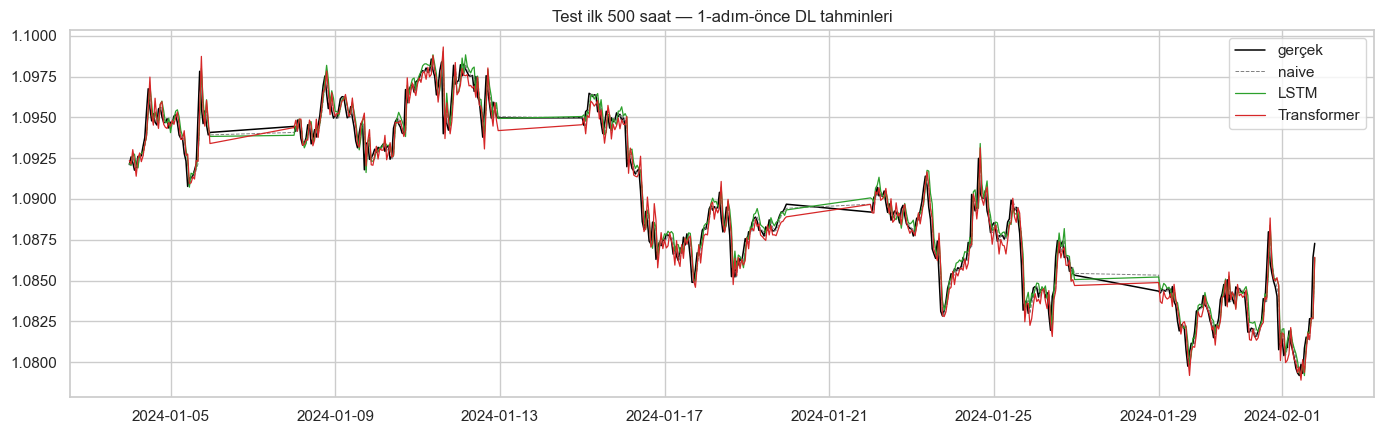

In [11]:
H = 500
test_seg = test.iloc[SEQ_LEN-1:]
idx = test_seg.index[:H]
prev = float(test.iloc[SEQ_LEN-2]['close']) if SEQ_LEN > 1 else float(val['close'].iloc[-1])
base = np.concatenate([[prev], test_seg['close'].values[:-1]])
actual = test_seg['close'].iloc[:H].values
naive_c = base[:H]
lstm_c  = (base * np.exp(test_pred_lstm))[:H]
tfm_c   = (base * np.exp(test_pred_tfm))[:H]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(idx, actual,  color='black',   lw=1.1, label='gerçek')
ax.plot(idx, naive_c, color='gray', ls='--', lw=0.7, label='naive')
ax.plot(idx, lstm_c,  color='tab:green', lw=0.9, label='LSTM')
ax.plot(idx, tfm_c,   color='tab:red',   lw=0.9, label='Transformer')
ax.set_title(f'Test ilk {H} saat — 1-adım-önce DL tahminleri')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'dl_pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Model Ağırlıklarını Kaydet

Streamlit demosu bu dosyaları yükleyip forward testing senaryosunu çalıştıracak.

In [12]:
CKPT_DIR = PROJECT_ROOT / 'data' / 'processed' / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)
torch.save({
    'state_dict': lstm.state_dict(),
    'config': {'input_size': len(FEATURE_COLS), 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2},
    'feature_cols': FEATURE_COLS, 'seq_len': SEQ_LEN,
    'feature_mu': mu.to_dict(), 'feature_sd': sd.to_dict(),
}, CKPT_DIR / 'lstm.pt')
torch.save({
    'state_dict': tfm.state_dict(),
    'config': {'input_size': len(FEATURE_COLS), 'seq_len': SEQ_LEN, 'd_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.1},
    'feature_cols': FEATURE_COLS, 'seq_len': SEQ_LEN,
    'feature_mu': mu.to_dict(), 'feature_sd': sd.to_dict(),
}, CKPT_DIR / 'transformer.pt')
print('Saved:', list(CKPT_DIR.glob('*.pt')))

Saved: [WindowsPath('C:/Users/Gaming/Desktop/MAC/yapay zeka ödev/data/processed/checkpoints/lstm.pt'), WindowsPath('C:/Users/Gaming/Desktop/MAC/yapay zeka ödev/data/processed/checkpoints/transformer.pt')]


## 10. Özet

**Beklenen sonuç:** LSTM ve Transformer, GBDT'lerle benzer bir bantta kalır. RMSE cephesinde fark pip'in onda biri mertebesinde; **yön doğruluğu** cephesinde kazanç varsa o da %0.5–1 puandır.

Bu kabaca **literatür gözlemi** ile tutarlıdır: forex gibi son derece verimli bir piyasada, sadece fiyat-tabanlı feature'larla 1-adım-önce tahmin için derin modellerin GBDT'den büyük farkla öne geçmesi nadirdir. DL'in güçlü yanları (pozisyon kodlayıcı, uzun bağımlılık) daha çok **çok-adım tahmin (multi-step forecasting)** ve **üretken simulasyon** bağlamında ortaya çıkar — bunları Hafta 8–9 (tuning + senaryo üretimi) ve Streamlit demosunda sömüreceğiz.

**Üretilenler:**

- `data/processed/dl_scores.csv` — LSTM + Transformer val/test skorları
- `data/processed/all_model_scores.csv` — tum 11 modelin birleşik tablosu (baseline + ML + DL)
- `data/processed/checkpoints/lstm.pt` ve `transformer.pt` — Streamlit demosunda yüklenecek ağırlıklar
- `docs/images/dl_*.png` — eğitim eğrileri, karşılaştırma ve tahmin grafikleri

**Sıradaki:** Hafta 7 metrik raporu (tüm modelleri tek belgede, walk-forward ve istatistiksel anlamlılık testleriyle).